In [43]:
import torch
import boto3
import pandas as pd
import numpy as np
import io
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
s3_client = boto3.client(
    's3', 
    endpoint_url='http://localstack:4566',
    # Como é LocalStack, podemos passar credenciais falsas qualquer
    aws_access_key_id='test',
    aws_secret_access_key='test',
    region_name='us-east-1'
)

bucket_name = 'data-extract'
archive_path = 'landing/01-07-2026/raw_PETR4.csv'

try:
    print(f"Baixando arquivo {archive_path} do bucket {bucket_name}...")
    # Recuperamos o arquivo do S3
    response = s3_client.get_object(Bucket=bucket_name, Key=archive_path)
    
    # Lemos o conteúdo do arquivo CSV em um DataFrame do Pandas
    bytes_data = response['Body'].read()
    df = pd.read_csv(io.BytesIO(bytes_data), header=[0, 1], index_col=0)
    # Ajustamos o DataFrame para remover o nível de cabeçalho extra
    df.columns = df.columns.droplevel(1)
    # Ajustamos os nomes das colunas e do índice
    df.columns.name = None
    df.index.name = 'Date'
    df = df.reset_index()
    
    print("Arquivo baixado com sucesso!")
    print("Exibindo as primeiras linhas do DataFrame:")
    print(df.head(1))
except Exception as e:
    print(f"Erro ao baixar o arquivo: {e}")

Baixando arquivo landing/01-07-2026/raw_PETR4.csv do bucket data-extract...
Arquivo baixado com sucesso!
Exibindo as primeiras linhas do DataFrame:
         Date     Close      High       Low      Open    Volume
0  2016-06-30  2.433882  2.451968  2.387375  2.433882  43741300


In [42]:
df.head(3)

,Date,Close,High,Low,Open,Volume
0,2016-06-30,2.433882,2.451968,2.387375,2.433882,43741300
1,2016-07-01,2.537231,2.544983,2.420963,2.449384,49290800
2,2016-07-04,2.550151,2.596658,2.529481,2.570821,24505100


# Plot de gráficos para cada ação
- **Gráfico de linha e colunas**: verificar outliers (picos em um dia que diminiu no próximo dia ou que não mantenham um padrão) que precisam ser removidos.
- **Histograma**: Verificamos como está o comportamento da linha, se ele mantem curva Gaussiana (formato de sino) ou tem caudas gordas, sendo nescessario a adição de Dropout para evitar o overfitting.
- **Heatmap**: Procuramos verificar como está a correlação das colunas Open, Close, High e Low, caso estejam em correlação 1.00 ou 0.99, consideramos usar somente o Close ou calculamos a diferença entre eles, pois seria a utilização de dados redudantes se usassemos as outras features e geraria custo computacional ao nosso modelo.


Analisando Ticker: PETR4


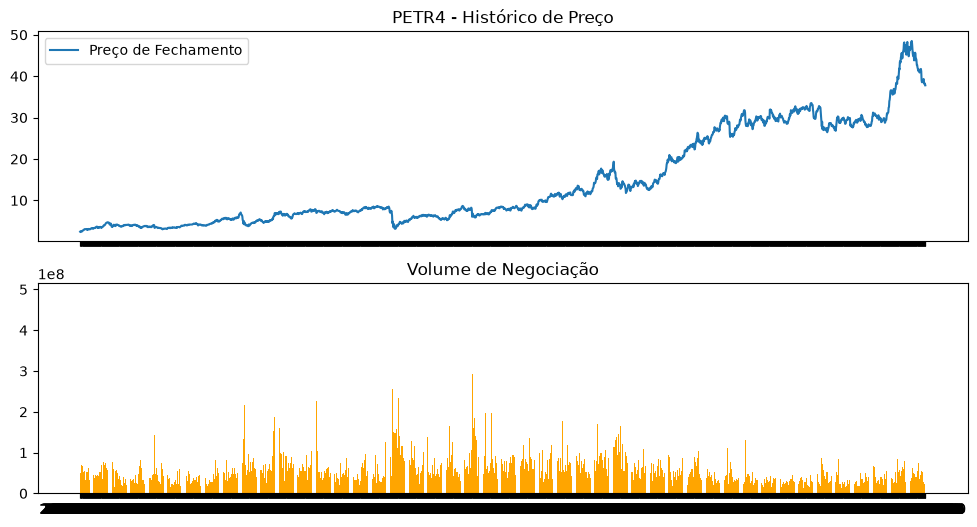

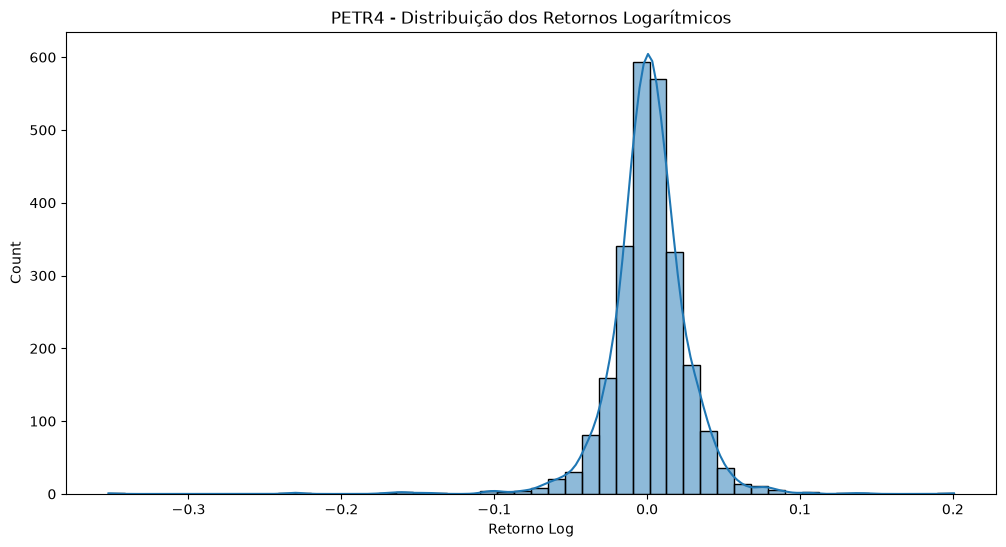

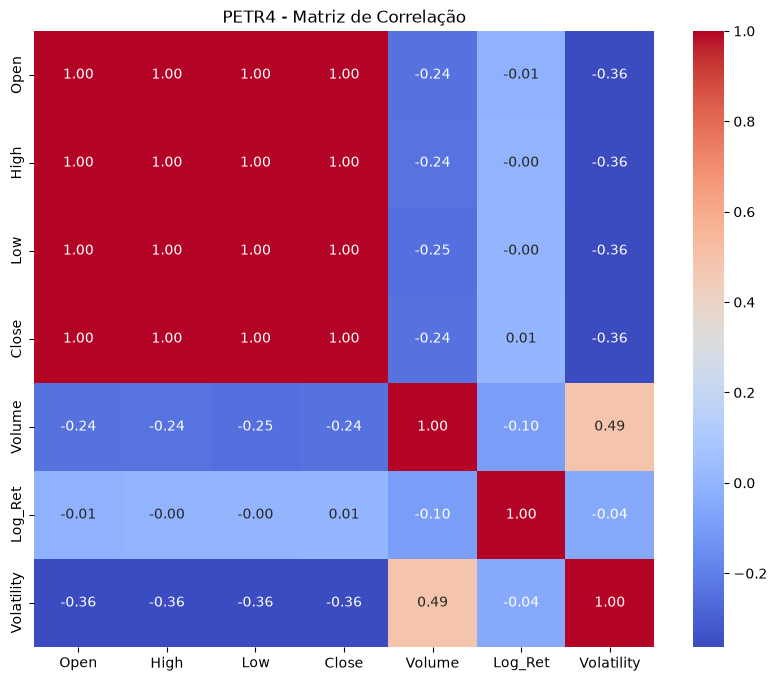

In [44]:
# Configurações de plotagem
plt.rcParams["figure.figsize"] = (12, 6)


print("\nAnalisando Ticker: PETR4")
df_t = df.copy()
    
# --- Visualização de Preço e Volume ---
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(df_t['Date'], df_t['Close'], label='Preço de Fechamento')
ax[0].set_title('PETR4 - Histórico de Preço')
ax[0].legend()
    
ax[1].bar(df_t['Date'], df_t['Volume'], color='orange', label='Volume')
ax[1].set_title('Volume de Negociação')
plt.show()
    
# --- Engenharia de Features para Deep Learning ---
# Retornos Logarítmicos (Melhor para DL que retornos simples)
df_t['Log_Ret'] = np.log(df_t['Close'] / df_t['Close'].shift(1))
    
# Volatilidade (Janela de 21 dias - ~1 mês útil)
df_t['Volatility'] = df_t['Log_Ret'].rolling(window=21).std()
    
# --- Distribuição dos Retornos (Normalidade) ---
plt.figure()
sns.histplot(df_t['Log_Ret'].dropna(), bins=50, kde=True)
plt.title('PETR4 - Distribuição dos Retornos Logarítmicos')
plt.xlabel('Retorno Log')
plt.show()
    
# --- Matriz de Correlação ---
# Verifica correlação entre as features brutas
cols_corr = ['Open', 'High', 'Low', 'Close', 'Volume', 'Log_Ret', 'Volatility']
plt.figure(figsize=(10, 8))
sns.heatmap(df_t[cols_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('PETR4 - Matriz de Correlação')
plt.show()

# Indetificação de outliers
Aqui estamos analisando o limite inferior e superior de todo conjunto de dado

In [45]:
q1 = np.percentile(df['Close'], 25)
q3 = np.percentile(df['Close'], 75)
iqr = q3 - q1

In [46]:
print(f"q1: {q1:.2f}, q3: {q3:.2f}, iqr: {iqr:.2f}")

q1: 5.65, q3: 25.85, iqr: 20.20


- Calculamos o limite inferior e superior do ativo

In [47]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
print(f"Limite Inferior: {limite_inferior:.2f}, Limite Superior: {limite_superior:.2f}")

Limite Inferior: -24.66, Limite Superior: 56.16


- Verificamos quantas outliers tem dentro desse dataset do ativo

In [49]:
outliers = np.where((df['Close'] < limite_inferior) | (df['Close'] > limite_superior))
print(f"Outliers encontrados: {len(outliers[0])}\n - Valores: {outliers}")

Outliers encontrados: 0
 - Valores: (array([], dtype=int64),)
